\begin{align}
\partial_t \eta + \partial_x \left( h u \right) + \partial_y \left( h u \right) & = 0 \\
\partial_t u - q h u + \partial_x \left( g \eta + K \right) & = \tau^x - \epsilon u + \nu \nabla^2 u \\
\partial_t v + q h v + \partial_y \left( g \eta + K \right) & = \tau^y - \epsilon v + \nu \nabla^2 v
\end{align}
where
\begin{align}
h & = D + \eta \\
K & = \frac{1}{2} \left( u^2 + v^2 \right) \\
q & = \frac{ f + \zeta }{ h } \\
\zeta & = \partial_x v - \partial_y u \\
f & = f_o + \beta y
\end{align}

\begin{align}
H^u & = \tilde{ h }^i \overline{ u^n }^i \\
h^* &= h^n - \Delta t \partial_x H^u \\
H^v & = \tilde{ h^* }^i \overline{ v^n }^i \\
h^{n+1} &= h^* - \Delta t \partial_y H^v \\
K^u_{i+1/2} & = \overline{ \max(0,u_i^n)^2 + \min(0,u_{i+1}^n)^2 }^j \\
K^v_{j+1/2} & = \overline{ \max(0,v_j^n)^2 + \min(0,v_{j+1}^n)^2 }^i \\
\frac{ u^{n+1} - u^n }{ \Delta t} - f \frac{v^{n+1} + v^n}{2} & =
\left( \tilde{q}^{j}H^v - f v^n \right) - \partial_x \left( g \eta^{n+1} + K^n \right) + \tau^x - \epsilon u^{n+1} + \nu \nabla^2 u^n \\
\frac{ v^{n+1} - v^n }{ \Delta t} + f \frac{u^{n+1} + u^n}{2} & =
\left( - \tilde{q}^{j}H^u + f u^n \right) - \partial_y \left( g \eta^{n+1} + K^n \right) + \tau^y - \epsilon v^{n+1} + \nu \nabla^2 v^n \\
\end{align}

\begin{align}
\left( 1 + \Delta t \epsilon \right) u^{n+1} - \frac{\Delta t f}{2} v^{n+1} & = u^* - \frac{\Delta t f}{2} v^n \\
u^* & = u^n + \Delta t
\left( \tilde{q}^{j}H^v - \partial_x \left( g \eta^{n+1} + K^n \right) + \tau^x + \nu \nabla^2 u^n \right) \\
\left( 1 + \Delta t \epsilon \right) v^{n+1} + \frac{\Delta t f}{2} v^{n+1} & = v^* + \frac{\Delta t f}{2} v^n \\
v^* & = v^n + \Delta t
\left( - \tilde{q}^{j}H^u - \partial_y \left( g \eta^{n+1} + K^n \right) + \tau^y + \nu \nabla^2 v^n \right)
\end{align}

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
class DQSWE:

    def __init__(self, ni, g, Do, Lx, fo, beta, epsilon):
        """
        ni      - Number of cells in i-direction
        g       - Gravity [m s-2]
        Do      - Max depth [m]
        Lx      - Domain width [m]
        fo      - Coriolss [s-1]
        beta    - df/dy [m-1 s-1]
        epsilon - Drag rate [s-1]
        """
        self.ni = ni
        self.g = g
        self.Do = Do
        self.Lx = Lx
        self.fo = fo
        self.beta = beta
        self.epsilon = epsilon
    
        # Grid resolution
        self.dx = Lx / ni # Cell width [m]
        
        # Limit to square domains/grids for now
        self.nj = self.ni
        self.Ly = self.Lx
        self.dy = self.dx

        # Grid
        self.x1, self.y1 = self.dx * ( np.arange(self.ni) + 0.5 ), self.dy * ( np.arange(self.nj) + 0.5 )
        self.x, self.y = np.meshgrid(self.x1, self.y1)

        # Initial conditions and bathymetry
        self.resting_state()
        self.flat_topog()

        # Forcing
        self.zero_forcing()

        # Derived parameters
        self.f = self.fo + self.beta * self.y
        cg = np.sqrt( self.g * self.Do )
        Ld = cg / self.fo
        print("cg =", cg, "[m s-1]")
        print("Ld =", Ld, "[m]")

    def resting_state(self):
        """Set state to resting (u=v=eta=0)"""
        self.u = np.zeros((self.nj,self.ni))
        self.v = np.zeros((self.nj,self.ni))
        self.eta = np.zeros((self.nj,self.ni))
        self.time = 0
        self.iter = 0

    def flat_topog(self):
        """Set bathymetry to flat with no boundaries"""
        self.D = self.Do + 0 * self.x

    def bowl_topog(self):
        """Set bathymetry to bowl shape"""
        self.D = self.Do * np.sin( self.x * np.pi / self.Lx ) * np.sin( self.y * np.pi / self.Ly )
        self.D[0,:] = 0 # Ensure land along southern edge
        self.D[:,0] = 0 # Ensure land along western edge
        self.D[-1,:] = 0 # Ensure land along northern edge
        self.D[:,-1] = 0 # Ensure land along eastern edge

    def zero_forcing(self):
        """Set winds to zero"""
        self.taux = 0 * self.y # zonal wind stress [m2 s-2]
        self.tauy = 0 * self.x # meridional wind stress [m2 s-2]

    def gyre_forcing(self):
        """Set winds to zonal gyre forcing"""
        self.taux = 0.1 * np.sin( self.y * np.pi / self.Ly ) # zonal wind stress [m2 s-2]
        self.tauy = 0 * self.x # meridional wind stress [m2 s-2]

    def run(self, dt, Trun, Tsamp):
        """
        dt   - Time step [s]
        Trun - Duration of run [s]
        Tsamp - Interval between samples [s]
        """
        print("CFL: dt*epsilon =", dt * self.epsilon )
        print("CFL: dt*f =", dt * np.abs( self.f.max() ) )
        cg = np.sqrt( self.g * self.Do )
        Ld = cg / self.fo
        print("CFL: dt*cg/dx =", dt * cg / self.dx)
        nsteps = int( Trun / dt )
        print("nsteps =", nsteps)
        samp_int = int( Tsamp / dt )
        print("samp_int =", samp_int)
        nsamp = int( Trun / Tsamp )
        print("nsamp =", nsamp)

        u = np.zeros((self.ni, self.nj, nsamp))
        v = np.zeros((self.ni, self.nj, nsamp))
        eta = np.zeros((self.ni, self.nj, nsamp))
        time = np.zeros((nsamp))

        nsamp = 0
        for iter in range( nsteps ):
            M.step( dt )
            if iter%samp_int==0:
                u[:,:,nsamp] = M.u.copy()
                v[:,:,nsamp] = M.v.copy()
                eta[:,:,nsamp] = M.eta.copy()
                time[nsamp] = M.time
                nsamp += 1
        return u, v, eta, time

    def step(self, dt):
        """
        dt   - Time step [s]
        """

        # Continuity equation (uses u,v at [n])
        h = self.D + self.eta # Total thickness
        uim1 = np.roll( self.u, +1, axis=1 )
        vjm1 = np.roll( self.v, +1, axis=1 )
        if self.iter%2==0:
            uw = ( uim1 + self.u ) / 2 # u on western edge
            hu = ( np.maximum( uw, 0 ) * np.roll( h, +1, axis=1 ) + np.minimum( uw, 0 ) * h ) # Upwinded h*u on western edge
            h = h - ( dt / self.dx ) * ( np.roll( hu, -1, axis=1 ) - hu )
            vs = ( vjm1 + self.v ) / 2 # v on southern edge
            hv = ( np.maximum( vs, 0 ) * np.roll( h, +1, axis=0 ) + np.minimum( vs, 0 ) * h ) # Upwinded h*v on southern edge
            self.eta = self.eta - ( dt / self.dy ) * ( np.roll( hv, -1, axis=0 ) - hv )
        else:
            vs = ( np.roll( self.v, +1, axis=1 ) + self.v ) / 2 # v on southern edge
            hv = ( np.maximum( vs, 0 ) * np.roll( h, +1, axis=0 ) + np.minimum( vs, 0 ) * h ) # Upwinded h*v on southern edge
            h = h - ( dt / self.dy ) * ( np.roll( hv, -1, axis=0 ) - hv )
            uw = ( np.roll( self.u, +1, axis=1 ) + self.u ) / 2 # u on western edge
            hu = ( np.maximum( uw, 0 ) * np.roll( h, +1, axis=1 ) + np.minimum( uw, 0 ) * h ) # Upwinded h*u on western edge
            self.eta = self.eta - ( dt / self.dx ) * ( np.roll( hu, -1, axis=1 ) - hu )
        h = self.D + self.eta # Update total thickness???

        # Explicit accelerations
        Ku = np.maximum( uim1, 0 )**2 + np.minimum( self.u, 0 )**2 # Enquist-Oscher u^2 at west edge
        Ku = 0.5 * ( np.roll( Ku, +1, axis=0) + Ku ) # u^2 at south-west corner
        Kv = np.maximum( vjm1, 0 )**2 + np.minimum( self.v, 0 )**2 # Enquist-Oscher v^2 at southern edge
        Kv = 0.5 * ( np.roll( Kv, +1, axis=1) + Kv) # v^2 at south-west corner
        E = 0.5 * ( np.roll( self.eta, +1, axis=1) + self.eta ) # eta at west edge
        E = 0.5 * ( np.roll( E, +1, axis=0) + E ) # eta at south-west corner
        B = E + 0.5 * ( Ku + Kv ) # Potential + KE at south-west corner

        Bx = ( np.roll( B, -1, axis=1) - B ) / self.dx
        Bx = 0.5 * ( np.roll( Bx, -1, axis=0) + Bx )
        By = ( np.roll( B, -1, axis=0) - B ) / self.dx
        By = 0.5 * ( np.roll( By, -1, axis=1) + By )

        ustar = self.taux
        ustar = self.u + dt * ustar

        vstar = self.tauy
        vstar = self.v + dt * vstar
        # Coriolis (Crank-Nicholson) and damping (Euler backward) update
        fdt = 0.5 * dt * self.f
        edtp1 = 1 + dt * self.epsilon
        det = 1 / ( edtp1**2 + fdt**2 )
        self.u = ( edtp1 * ustar + fdt * vstar ) * det
        self.v = ( edtp1 * vstar - fdt * ustar ) * det

        self.time = self.time + dt
        self.iter = self.iter + 1

M = DQSWE(16,
          10., # Gravity [m s-2]
          1000., # Max depth [m]
          1000.e3, # Domain width [m]
          1.e-4, # Coriolss [s-1]
          0.e-11, # df/dy [m-1 s-1]
          0.e-6 # Drag rate [s-1]
          )
M.step(50.)
M.resting_state()
M.gyre_forcing()

cg = 100.0 [m s-1]
Ld = 1000000.0 [m]


In [3]:
M.resting_state()
u, v, eta, time = M.run(1000., 2.e5, 1000.)
M.time

CFL: dt*epsilon = 0.0
CFL: dt*f = 0.1
CFL: dt*cg/dx = 1.6
nsteps = 200
samp_int = 1
nsamp = 200


200000.0

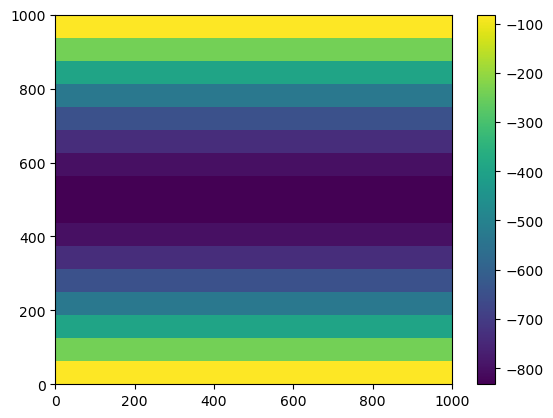

In [4]:
plt.pcolormesh(M.x1/1e3, M.y1/1e3, u[:,:,-1]); plt.colorbar();

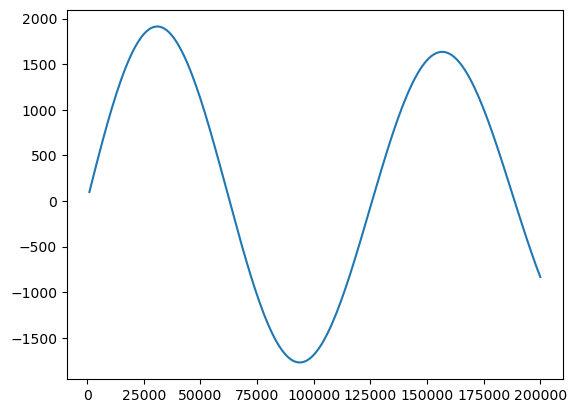

In [5]:
plt.plot(time, u[8,0]);

In [6]:
time

array([  1000.,   2000.,   3000.,   4000.,   5000.,   6000.,   7000.,
         8000.,   9000.,  10000.,  11000.,  12000.,  13000.,  14000.,
        15000.,  16000.,  17000.,  18000.,  19000.,  20000.,  21000.,
        22000.,  23000.,  24000.,  25000.,  26000.,  27000.,  28000.,
        29000.,  30000.,  31000.,  32000.,  33000.,  34000.,  35000.,
        36000.,  37000.,  38000.,  39000.,  40000.,  41000.,  42000.,
        43000.,  44000.,  45000.,  46000.,  47000.,  48000.,  49000.,
        50000.,  51000.,  52000.,  53000.,  54000.,  55000.,  56000.,
        57000.,  58000.,  59000.,  60000.,  61000.,  62000.,  63000.,
        64000.,  65000.,  66000.,  67000.,  68000.,  69000.,  70000.,
        71000.,  72000.,  73000.,  74000.,  75000.,  76000.,  77000.,
        78000.,  79000.,  80000.,  81000.,  82000.,  83000.,  84000.,
        85000.,  86000.,  87000.,  88000.,  89000.,  90000.,  91000.,
        92000.,  93000.,  94000.,  95000.,  96000.,  97000.,  98000.,
        99000., 1000